# **1. Setup & Imports**

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"abdonassar101","key":"26c251cad273e9a2b90c8b15359121b2"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d ealaxi/paysim1
!unzip paysim1.zip
!ls -lh

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:09<00:00, 18.7MB/s]

Archive:  paysim1.zip
  inflating: PS_20174392719_1491204439457_log.csv  
total 649M
-rw-r--r-- 1 root root   69 May  1 22:53 kaggle.json
-rw-r--r-- 1 root root 178M Sep 20  2019 paysim1.zip
-rw-r--r-- 1 root root 471M Sep 20  2019 PS_20174392719_1491204439457_log.csv
drwxr-xr-x 1 root root 4.0K Apr 16 13:33 sample_data


In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, recall_score, precision_score, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler

## **2. Data Loading**

In [6]:
df_raw = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [7]:
print("Shape:", df_raw.shape)

df_raw.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# **3. Data Understanding**

In [8]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
df_raw.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [10]:
df_raw.duplicated().sum()

np.int64(0)

In [11]:
num_cols = df_raw.select_dtypes(include=np.number).columns
cat_cols = df_raw.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 8
Categorical Columns: 3


In [12]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [13]:
fraud_counts = df_raw['isFraud'].value_counts()
fraud_percent = df_raw['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_percent)

isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [14]:
df_raw['type'].value_counts()

,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [15]:
df_raw[(df_raw['type'] == 'TRANSFER') & (df_raw['isFraud'] == 1)].shape
df_raw[(df_raw['type'] == 'CASH_OUT') & (df_raw['isFraud'] == 1)].shape

(4116, 11)

In [16]:
df_raw.groupby('step')['isFraud'].mean().head()

,isFraud
step,
1,0.005908
2,0.007890
3,0.007246
4,0.017699
5,0.009023


In [17]:
df_raw.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [18]:
df_raw['nameOrig'].nunique(), df_raw['nameDest'].nunique()

(6353307, 2722362)

# **4. EDA**

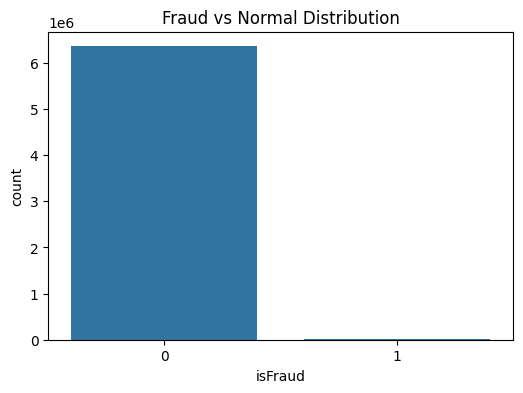

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df_raw)
plt.title("Fraud vs Normal Distribution")
plt.show()

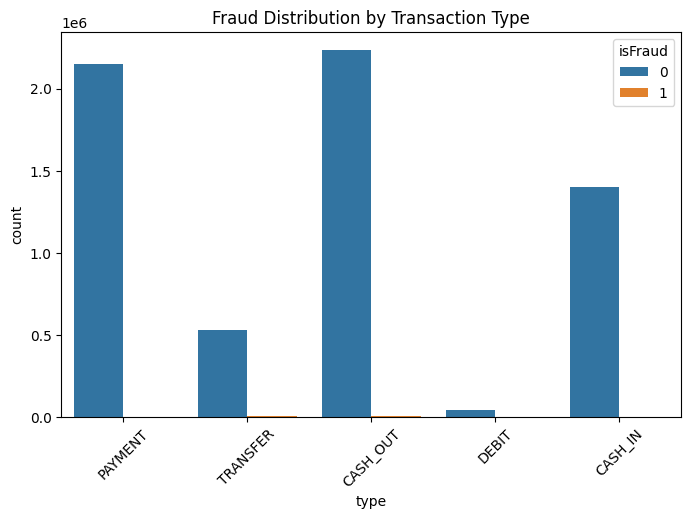

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_raw, x='type', hue='isFraud')
plt.title("Fraud Distribution by Transaction Type")
plt.xticks(rotation=45)
plt.show()

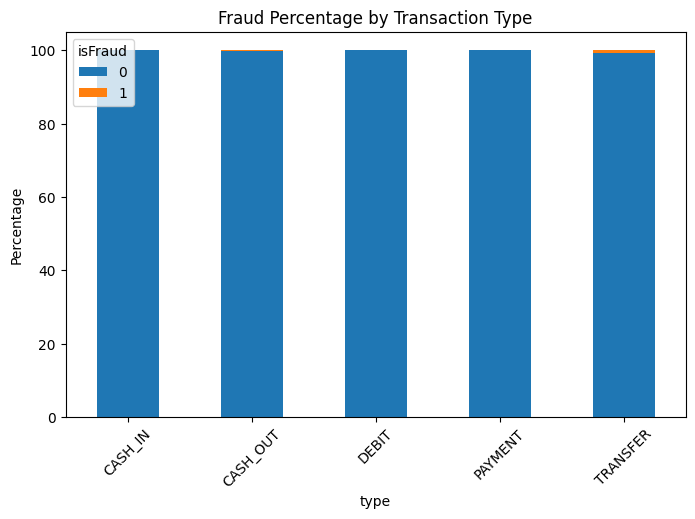

In [21]:
fraud_ratio = pd.crosstab(df_raw['type'], df_raw['isFraud'], normalize='index') * 100

fraud_ratio.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Fraud Percentage by Transaction Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

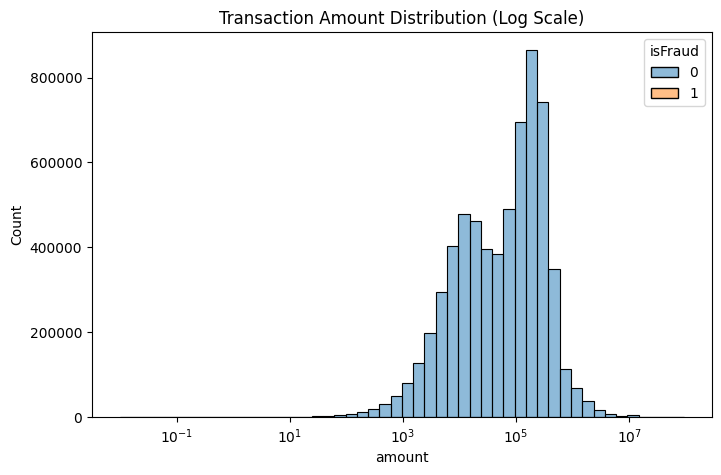

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_raw, x='amount', hue='isFraud', bins=50, log_scale=True)
plt.title("Transaction Amount Distribution (Log Scale)")
plt.show()

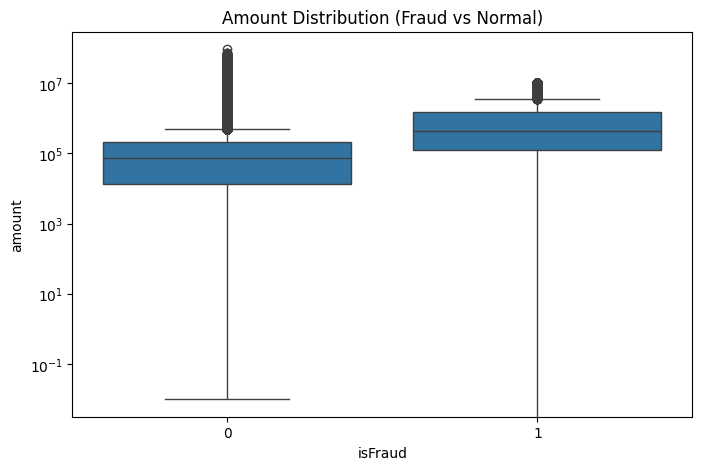

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_raw, x='isFraud', y='amount')
plt.yscale('log')
plt.title("Amount Distribution (Fraud vs Normal)")
plt.show()

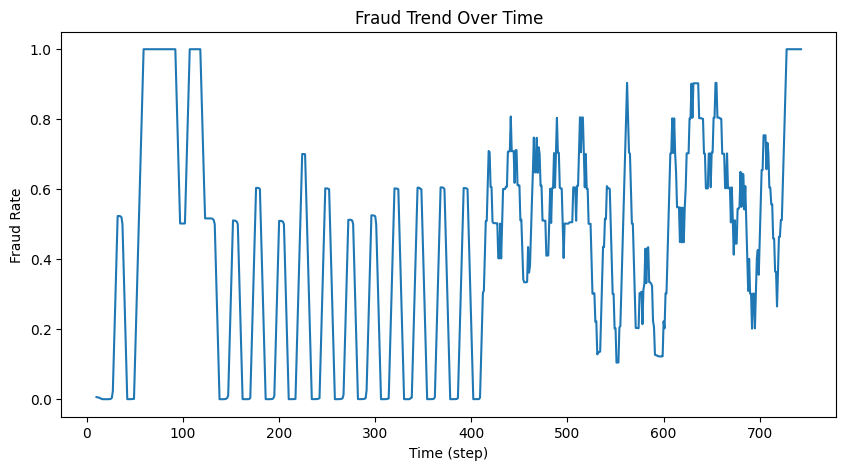

In [24]:
fraud_time = df_raw.groupby('step')['isFraud'].mean().rolling(10).mean()

plt.figure(figsize=(10,5))
fraud_time.plot()
plt.title("Fraud Trend Over Time")
plt.xlabel("Time (step)")
plt.ylabel("Fraud Rate")
plt.show()

In [25]:
print("Top Fraud Transactions:")
print(df_raw[df_raw['isFraud'] == 1]['amount'].sort_values(ascending=False).head(10))

Top Fraud Transactions:
6362529    10000000.0
4440       10000000.0
4441       10000000.0
6362579    10000000.0
6362578    10000000.0
6362577    10000000.0
6362576    10000000.0
6362528    10000000.0
6266409    10000000.0
6266410    10000000.0
Name: amount, dtype: float64


In [26]:
print("\nFraud Transactions per User:")
print(df_raw[df_raw['isFraud'] == 1].groupby('nameOrig').size().describe())


Fraud Transactions per User:
count    8213.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64


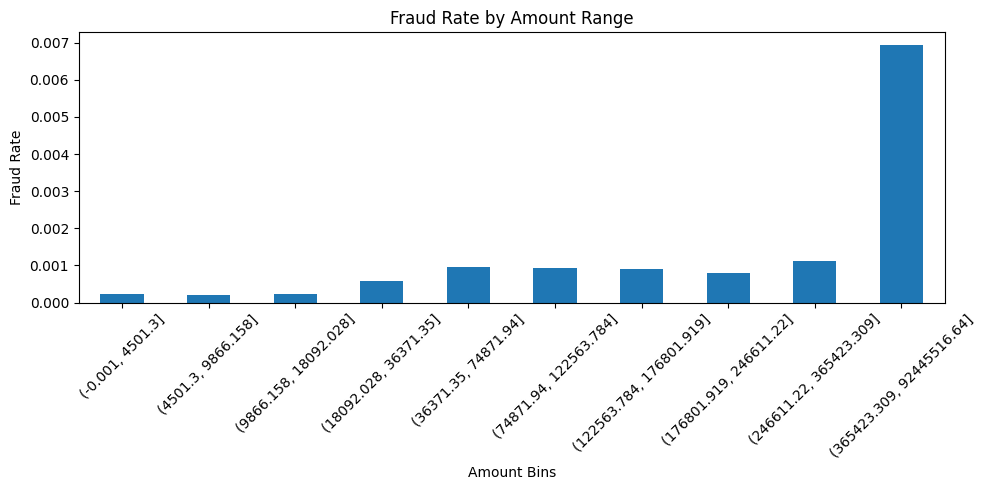

In [27]:
df_raw['amount_bin'] = pd.qcut(df_raw['amount'], q=10, duplicates='drop')

fraud_by_amount = df_raw.groupby('amount_bin', observed=True)['isFraud'].mean()

plt.figure(figsize=(10,5))
fraud_by_amount.plot(kind='bar')
plt.title("Fraud Rate by Amount Range")
plt.xlabel("Amount Bins")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_raw.drop(columns=['amount_bin'], inplace=True)

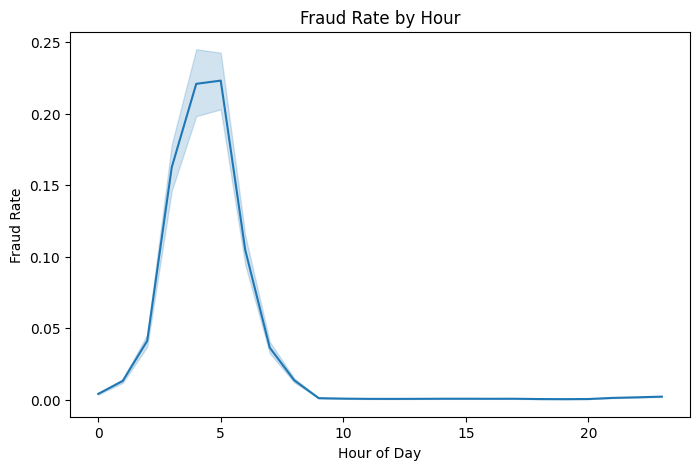

In [28]:
df_raw['hour'] = df_raw['step'] % 24

plt.figure(figsize=(8,5))
sns.lineplot(x=df_raw['hour'], y=df_raw['isFraud'])
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

df_raw.drop(columns=['hour'], inplace=True)

# **5. Data Cleaning**

In [29]:
df_raw.drop(columns=[
    'isFlaggedFraud',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
], inplace=True)

In [30]:
df_raw['amount_log'] = np.log1p(df_raw['amount'])

# **6. Train/Test Split**

In [31]:
import gc

df_raw = df_raw.sort_values(by='step').reset_index(drop=True)

split_idx = int(len(df_raw) * 0.8)
train_full = df_raw.iloc[:split_idx].copy()
test_df = df_raw.iloc[split_idx:].copy().reset_index(drop=True)

def final_train_sampling(df, non_fraud_frac=0.05):
    fraud = df[df['isFraud'] == 1]
    non_fraud = df[df['isFraud'] == 0].sample(frac=non_fraud_frac, random_state=42)

    return pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

train_df = final_train_sampling(train_full, non_fraud_frac=0.05)

del train_full, df_raw
gc.collect()

print(f"Train Shape: {train_df.shape} | Test Shape: {test_df.shape}")
print(f"Fraud in Train: {train_df.isFraud.sum()} ({train_df.isFraud.mean():.4%})")
print(f"Fraud in Test:  {test_df.isFraud.sum()} ({test_df.isFraud.mean():.4%})")

Train Shape: (258266, 7) | Test Shape: (1272524, 7)
Fraud in Train: 3959 (1.5329%)
Fraud in Test:  4254 (0.3343%)


# **7. Feature Engineering**

In [32]:
for df_ in [train_df, test_df]:
    df_['hour'] = df_['step'] % 24
    df_['is_night'] = (df_['hour'] < 6).astype(int)

In [33]:
amount_95 = train_df['amount'].quantile(0.95)
amount_99 = train_df['amount'].quantile(0.99)

for df_ in [train_df, test_df]:
    df_['amount_log'] = np.log1p(df_['amount'])
    df_['is_high_amount'] = (df_['amount'] > amount_95).astype(int)
    df_['is_very_high_amount'] = (df_['amount'] > amount_99).astype(int)

In [34]:
for df_ in [train_df, test_df]:
    df_['dest_is_merchant'] = df_['nameDest'].str.startswith('M').astype(int)

In [35]:
train_df = train_df.sort_values(['nameOrig', 'step'])

train_df['user_tx_count'] = train_df.groupby('nameOrig').cumcount()

train_df['user_avg_amount'] = (
    train_df.groupby('nameOrig')['amount']
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
).fillna(0)

train_df['last_amount'] = (
    train_df.groupby('nameOrig')['amount']
    .shift()
).fillna(0)

In [36]:
user_avg_map = train_df.groupby('nameOrig')['amount'].mean()
last_amount_map = train_df.groupby('nameOrig')['amount'].last()

test_df['user_avg_amount'] = test_df['nameOrig'].map(user_avg_map).fillna(0)
test_df['last_amount'] = test_df['nameOrig'].map(last_amount_map).fillna(0)

In [37]:
for df_ in [train_df, test_df]:
    df_['amount_vs_avg'] = df_['amount'] - df_['user_avg_amount']
    df_['amount_ratio_avg'] = df_['amount'] / (df_['user_avg_amount'] + 1e-6)
    df_['amount_ratio_last'] = df_['amount'] / (df_['last_amount'] + 1e-6)

In [38]:
dest_count_map = train_df['nameDest'].value_counts()

for df_ in [train_df, test_df]:
    df_['dest_popularity'] = df_['nameDest'].map(dest_count_map).fillna(0)
    df_['is_new_destination'] = (df_['dest_popularity'] == 0).astype(int)

In [39]:
important_types = ['TRANSFER', 'CASH_OUT']

for df_ in [train_df, test_df]:
    for t in important_types:
        df_[f'type_{t}'] = (df_['type'] == t).astype(int)

    df_['high_transfer_risk'] = df_['type_TRANSFER'] * df_['is_high_amount']

In [40]:
cols_to_drop = ['nameOrig', 'nameDest', 'type', 'step']

X_train = train_df.drop(columns=['isFraud'] + cols_to_drop, errors='ignore')
y_train = train_df['isFraud']

X_test = test_df.drop(columns=['isFraud'] + cols_to_drop, errors='ignore')
y_test = test_df['isFraud']

In [41]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

print("FINAL FEATURE ENGINEERING DONE")
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)
print("Total Features:", len(X_train.columns))
print("Features:", list(X_train.columns))

FINAL FEATURE ENGINEERING DONE
Train Shape: (258266, 18)
Test Shape : (1272524, 18)
Total Features: 18
Features: ['amount', 'amount_log', 'hour', 'is_night', 'is_high_amount', 'is_very_high_amount', 'dest_is_merchant', 'user_tx_count', 'user_avg_amount', 'last_amount', 'amount_vs_avg', 'amount_ratio_avg', 'amount_ratio_last', 'dest_popularity', 'is_new_destination', 'type_TRANSFER', 'type_CASH_OUT', 'high_transfer_risk']


# **8. Feature Check**

isFraud                1.000000
is_very_high_amount    0.242739
is_high_amount         0.221968
amount_ratio_last      0.206318
amount                 0.206318
is_night               0.187275
type_TRANSFER          0.178202
amount_vs_avg          0.144648
amount_log             0.132922
high_transfer_risk     0.113932
type_CASH_OUT          0.038209
user_avg_amount        0.001975
amount_ratio_avg      -0.000446
last_amount           -0.000609
user_tx_count         -0.000776
dest_popularity       -0.001508
step                  -0.023128
dest_is_merchant      -0.088121
hour                  -0.099979
is_new_destination          NaN
Name: isFraud, dtype: float64


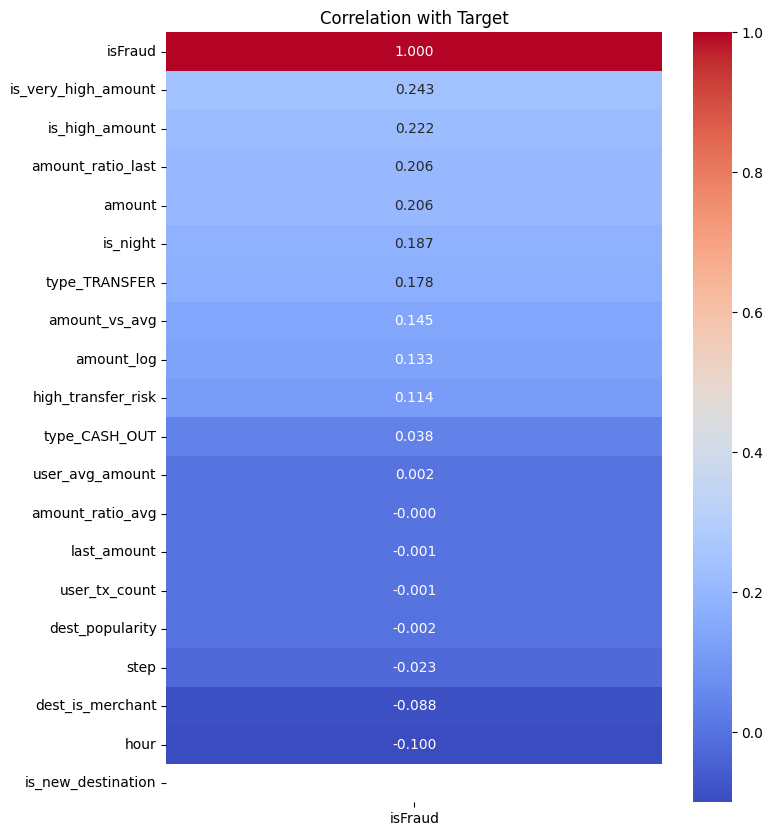

In [42]:
corr = train_df.corr(numeric_only=True)

corr_target = corr['isFraud'].sort_values(ascending=False)
print(corr_target)

plt.figure(figsize=(8,10))
sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt=".3f"
)
plt.title("Correlation with Target")
plt.show()

In [43]:
cols_to_drop = [
'step',
'amount',
'user_avg_amount',
'last_amount',
'amount_ratio_avg',
'user_tx_count',
'dest_popularity',
'hour',
'is_new_destination'
]

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df  = test_df.drop(columns=cols_to_drop, errors='ignore')

print("Remaining features in train:", train_df.shape)
print("Remaining features in test:", test_df.shape)

Remaining features in train: (258266, 14)
Remaining features in test: (1272524, 14)


# **9. Handling Imbalance**

In [44]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(scale_pos_weight)

64.2351603940389


# **10. Models**

### **Evaluation Function**

In [45]:
def evaluate_model(name, y_train, y_test, train_proba, test_proba, threshold=0.5):

    train_pred = (train_proba >= threshold).astype(int)
    test_pred  = (test_proba >= threshold).astype(int)

    print(f"\n================ {name} ================")

    print("\n--- TRAIN ---")
    print("Accuracy :", accuracy_score(y_train, train_pred))
    print("Precision:", precision_score(y_train, train_pred))
    print("Recall   :", recall_score(y_train, train_pred))
    print("ROC-AUC  :", roc_auc_score(y_train, train_proba))

    print("\n--- TEST ---")
    print("Accuracy :", accuracy_score(y_test, test_pred))
    print("Precision:", precision_score(y_test, test_pred))
    print("Recall   :", recall_score(y_test, test_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, test_proba))

    print("\n--- OVERFITTING CHECK ---")
    print("AUC GAP:", roc_auc_score(y_train, train_proba) - roc_auc_score(y_test, test_proba))

## **XGBoost Model**

In [46]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    reg_alpha=1,
    reg_lambda=2,
    eval_metric='auc',
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_train_proba = xgb_model.predict_proba(X_train)[:,1]
xgb_test_proba  = xgb_model.predict_proba(X_test)[:,1]

evaluate_model(
    "XGBoost",
    y_train, y_test,
    xgb_train_proba,
    xgb_test_proba
)


================ XGBoost ================

--- TRAIN ---
Accuracy : 0.907018345426808
Precision: 0.12823935046157267
Recall   : 0.8737054811821167
ROC-AUC  : 0.9646554990482518

--- TEST ---
Accuracy : 0.906875626707237
Precision: 0.02954135542689606
Recall   : 0.8432063939821345
ROC-AUC  : 0.9512979270070919

--- OVERFITTING CHECK ---
AUC GAP: 0.013357572041159838


## **LightGBM Model**

In [47]:
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=20,
    subsample=0.7,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
lgb_model.fit(X_train, y_train)

lgb_train_proba = lgb_model.predict_proba(X_train)[:,1]
lgb_test_proba  = lgb_model.predict_proba(X_test)[:,1]

evaluate_model(
    "LightGBM",
    y_train, y_test,
    lgb_train_proba,
    lgb_test_proba
)

[LightGBM] [Info] Number of positive: 3959, number of negative: 254307
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1579
[LightGBM] [Info] Number of data points in the train set: 258266, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015329 -> initscore=-4.162551
[LightGBM] [Info] Start training from score -4.162551

================ LightGBM ================

--- TRAIN ---
Accuracy : 0.909813912787591
Precision: 0.13424647167883763
Recall   : 0.8961859055317
ROC-AUC  : 0.9725342037238479

--- TEST ---
Accuracy : 0.9061196488239122
Precision: 0.028854883165531173
Recall   : 0.8293370944992948
ROC-AUC  : 0.9501973940609486

--- OVERFITTING CHECK ---
AUC GAP: 0.022336809662899304


## **CatBoost Model**

In [48]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function='Logloss',
    auto_class_weights='Balanced',
    verbose=0,
    random_seed=42
)

cat_model.fit(X_train, y_train)

cat_train_proba = cat_model.predict_proba(X_train)[:,1]
cat_test_proba  = cat_model.predict_proba(X_test)[:,1]

evaluate_model(
    "CatBoost",
    y_train, y_test,
    cat_train_proba,
    cat_test_proba
)


================ CatBoost ================

--- TRAIN ---
Accuracy : 0.9003159533194458
Precision: 0.11920576102915473
Recall   : 0.8613286183379641
ROC-AUC  : 0.9596177280096845

--- TEST ---
Accuracy : 0.8942267493579689
Precision: 0.02656564409155958
Recall   : 0.8596614950634697
ROC-AUC  : 0.9521593585150507

--- OVERFITTING CHECK ---
AUC GAP: 0.007458369494633743


# **Ensemble System**

In [49]:
def ensemble_predict_proba(X):
    xgb_p = xgb_model.predict_proba(X)[:, 1]
    lgb_p = lgb_model.predict_proba(X)[:, 1]
    cat_p = cat_model.predict_proba(X)[:, 1]

    return (
        0.3 * xgb_p +
        0.3 * lgb_p +
        0.4 * cat_p
    )

In [50]:
from sklearn.metrics import precision_recall_curve

probs = ensemble_predict_proba(X_test)

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

best_threshold = thresholds[f1.argmax()]

print("Best Threshold:", best_threshold)

Best Threshold: 0.9814190297001124


In [51]:
BEST_THRESHOLD = best_threshold
AGGRESSIVE_THRESHOLD = 0.90
CONSERVATIVE_THRESHOLD = 0.99

def predict(X, mode="best"):
    probs = ensemble_predict_proba(X)

    if mode == "best":
        threshold = BEST_THRESHOLD

    elif mode == "conservative":
        threshold = CONSERVATIVE_THRESHOLD

    elif mode == "aggressive":
        threshold = AGGRESSIVE_THRESHOLD

    else:
        raise ValueError("Mode must be: best / conservative / aggressive")

    return (probs >= threshold).astype(int)

In [52]:
def predict_risk(X):
    probs = ensemble_predict_proba(X)

    return np.where(
        probs >= 0.99, "HIGH RISK",
        np.where(probs >= 0.95, "MEDIUM RISK", "LOW RISK")
    )

In [53]:
def evaluate_ensemble(mode="best"):

    train_proba = ensemble_predict_proba(X_train)
    test_proba  = ensemble_predict_proba(X_test)

    print("\n================ ENSEMBLE SYSTEM ================")

    print("\n--- TRAIN ---")
    print("ROC-AUC :", roc_auc_score(y_train, train_proba))

    print("\n--- TEST ---")
    print("ROC-AUC :", roc_auc_score(y_test, test_proba))

    print("\n--- GENERALIZATION ---")
    print("AUC GAP :", roc_auc_score(y_train, train_proba) - roc_auc_score(y_test, test_proba))

In [54]:
evaluate_ensemble(mode="best")

for mode in ["aggressive", "best", "conservative"]:
    print(f"\n===== {mode.upper()} MODE =====")
    y_pred = predict(X_test, mode=mode)

    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))


================ ENSEMBLE SYSTEM ================

--- TRAIN ---
ROC-AUC : 0.9664230293447156

--- TEST ---
ROC-AUC : 0.951918060039725

--- GENERALIZATION ---
AUC GAP : 0.014504969304990567

===== AGGRESSIVE MODE =====
Precision: 0.15923349699945444
Recall   : 0.5488951574988247

===== BEST MODE =====
Precision: 0.608336610302792
Recall   : 0.3636577338975082

===== CONSERVATIVE MODE =====
Precision: 0.741130820399113
Recall   : 0.3142924306535026


In [55]:
def predict_full(X):
    probs = ensemble_predict_proba(X)
    labels = predict(X, mode="best")
    risk = predict_risk(X)

    return pd.DataFrame({
        "fraud_probability": probs,
        "prediction": labels,
        "risk_level": risk
    })

# **11. Feature Importance**


<Figure size 1000x600 with 0 Axes>

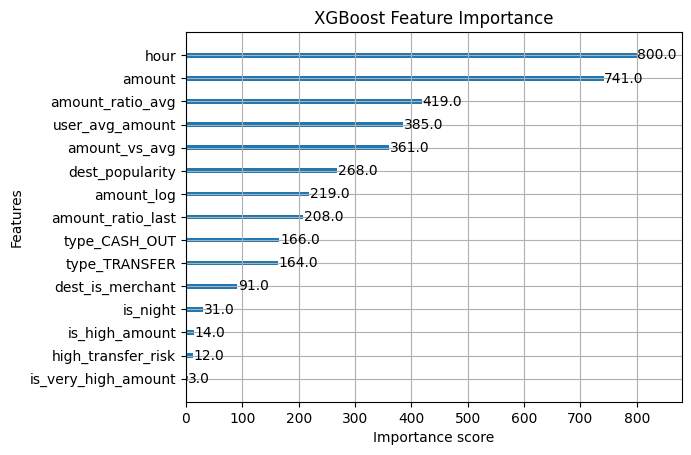

In [56]:
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(xgb_model, max_num_features=15)
plt.title("XGBoost Feature Importance")
plt.show()

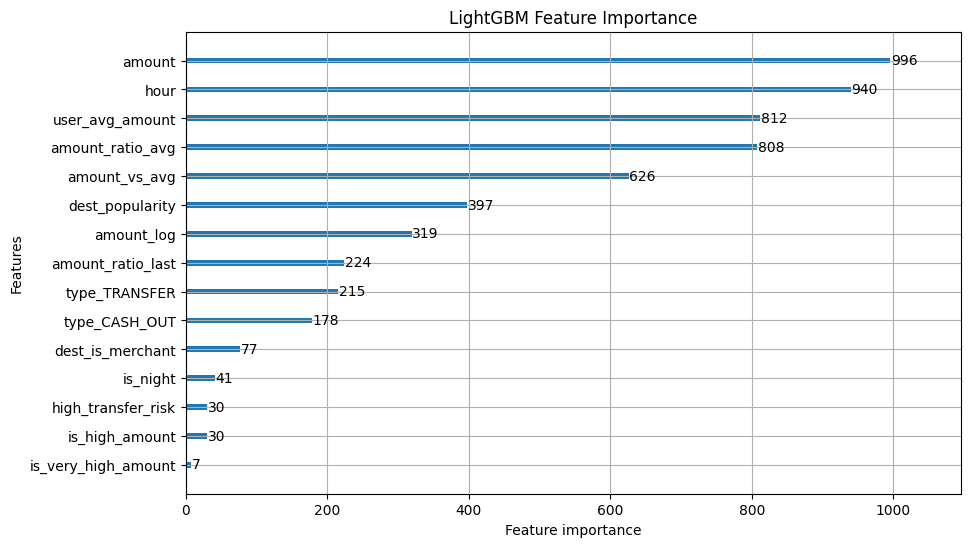

In [57]:
import lightgbm as lgb

lgb.plot_importance(lgb_model, max_num_features=15, figsize=(10,6))
plt.title("LightGBM Feature Importance")
plt.show()

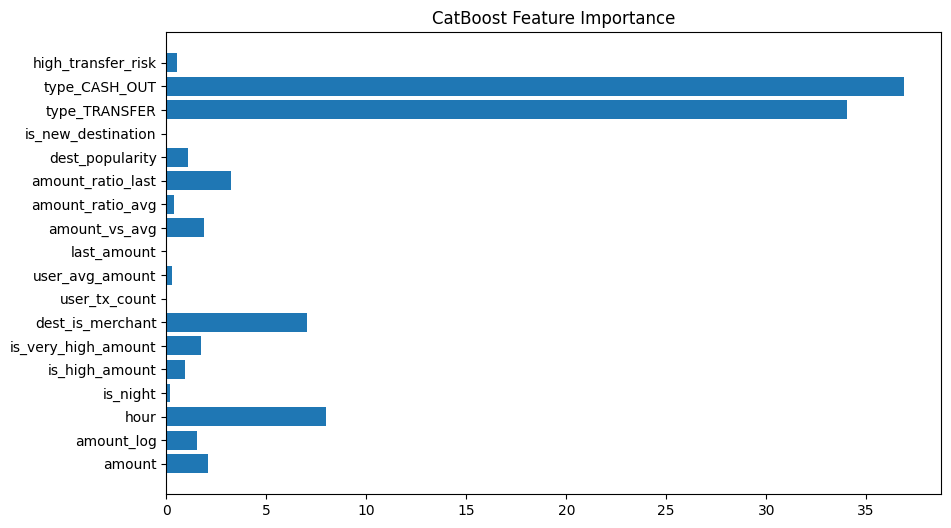

In [58]:
from catboost import Pool

feature_importance = cat_model.get_feature_importance()
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, feature_importance)
plt.title("CatBoost Feature Importance")
plt.show()

## **12. Save the models**

In [59]:
! pip install fastapi uvicorn joblib

In [60]:
import joblib

joblib.dump(xgb_model, "xgb.pkl")
joblib.dump(lgb_model, "lgb.pkl")
joblib.dump(cat_model, "cat.pkl")

['cat.pkl']

# **13. Gradio Deployment**

In [61]:
import gradio as gr

try:
    xgb_model = joblib.load("xgb.pkl")
    lgb_model = joblib.load("lgb.pkl")
    cat_model = joblib.load("cat.pkl")
    print("All models loaded successfully!")
except Exception as e:
    print(f"Error loading models: {e}")

All models loaded successfully!


In [62]:
def build_features(
    amount, hour, is_high_amount, is_very_high_amount, dest_is_merchant,
    user_tx_count, user_avg_amount, last_amount, dest_popularity,
    is_new_destination, type_TRANSFER, type_CASH_OUT
):

    amount = max(amount, 0)
    hour = int(np.clip(hour, 0, 23))
    user_tx_count = max(user_tx_count, 0)
    user_avg_amount = max(user_avg_amount, 1)
    last_amount = max(last_amount, 1)
    dest_popularity = max(dest_popularity, 0)

    amount = min(amount, 1e7)

    is_night = 1 if hour < 6 else 0
    amount_log = np.log1p(amount)

    amount_vs_avg = amount - user_avg_amount

    amount_ratio_avg = min(amount / user_avg_amount, 1e6)
    amount_ratio_last = min(amount / last_amount, 1e6)

    high_transfer_risk = type_TRANSFER * is_high_amount

    feature_order = [
        'amount',
        'amount_log',
        'hour',
        'is_night',
        'is_high_amount',
        'is_very_high_amount',
        'dest_is_merchant',
        'user_tx_count',
        'user_avg_amount',
        'last_amount',
        'amount_vs_avg',
        'amount_ratio_avg',
        'amount_ratio_last',
        'dest_popularity',
        'is_new_destination',
        'type_TRANSFER',
        'type_CASH_OUT',
        'high_transfer_risk'
    ]

    data = {
        'amount': amount,
        'amount_log': amount_log,
        'hour': hour,
        'is_night': is_night,
        'is_high_amount': is_high_amount,
        'is_very_high_amount': is_very_high_amount,
        'dest_is_merchant': dest_is_merchant,
        'user_tx_count': user_tx_count,
        'user_avg_amount': user_avg_amount,
        'last_amount': last_amount,
        'amount_vs_avg': amount_vs_avg,
        'amount_ratio_avg': amount_ratio_avg,
        'amount_ratio_last': amount_ratio_last,
        'dest_popularity': dest_popularity,
        'is_new_destination': is_new_destination,
        'type_TRANSFER': type_TRANSFER,
        'type_CASH_OUT': type_CASH_OUT,
        'high_transfer_risk': high_transfer_risk
    }

    return pd.DataFrame([data])[feature_order].astype(np.float32)

In [63]:
def predict_fraud(
    amount, hour, is_high_amount, is_very_high_amount, dest_is_merchant,
    user_tx_count, user_avg_amount, last_amount, dest_popularity,
    is_new_destination, type_TRANSFER, type_CASH_OUT
):
    try:

        X = build_features(
            amount, hour, is_high_amount, is_very_high_amount,
            dest_is_merchant, user_tx_count, user_avg_amount,
            last_amount, dest_popularity, is_new_destination,
            type_TRANSFER, type_CASH_OUT
        )

        p_xgb = xgb_model.predict_proba(X)[:, 1][0]
        p_lgb = lgb_model.predict_proba(X)[:, 1][0]
        p_cat = cat_model.predict_proba(X)[:, 1][0]

        prob = (0.3 * p_xgb) + (0.3 * p_lgb) + (0.4 * p_cat)

        if prob >= 0.95:
            risk = "HIGH (Critical)"
            status = "FRAUD DETECTED"

        elif prob >= 0.80:
            risk = "MEDIUM (Suspicious)"
            status = "REVIEW REQUIRED"

        else:
            risk = "LOW (Safe)"
            status = "NORMAL TRANSACTION"

        return {
            "Final Decision": status,
            "Fraud Probability": f"{prob*100:.2f}%",
            "Risk Level": risk,
            "Ensemble Confidence": round(float(prob), 4)
        }

    except Exception as e:
        return {
            "Error": "Prediction failed",
            "Details": str(e)
        }

In [64]:
app = gr.Interface(
    fn=predict_fraud,
    inputs=[
        gr.Number(label="Transaction Amount ($)", value=5000),
        gr.Slider(0, 23, label="Hour of Day (0-23)", value=12),
        gr.Dropdown([0, 1], label="Is High Amount? (Top 5%)", value=0),
        gr.Dropdown([0, 1], label="Is Very High Amount? (Top 1%)", value=0),
        gr.Dropdown([0, 1], label="Destination is Merchant?", value=0),
        gr.Number(label="User Transaction Count", value=1),
        gr.Number(label="User Historical Average Amount", value=1000),
        gr.Number(label="Last Transaction Amount", value=500),
        gr.Number(label="Destination Global Popularity", value=1),
        gr.Dropdown([0, 1], label="Is New Destination for User?", value=1),
        gr.Dropdown([0, 1], label="Type: TRANSFER (0=No, 1=Yes)", value=1),
        gr.Dropdown([0, 1], label="Type: CASH_OUT (0=No, 1=Yes)", value=0)
    ],
    outputs="json",
    title="Enterprise Financial Fraud Detection System",
    description="Production-ready fraud detection system with stable inference pipeline."
)

In [65]:
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://73a0f8c08d6ee53039.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **The end**